# Detection frequency vs. detectability — correlation (US + Global)

**Reviewer response (L454):** quantify how *detection frequency* correlates with
*detectability*, as a correlation coefficient for both the US and global datasets.

**Manuscript definitions:**
- **Detection** — binary label per TROPOMI overpass (1 = significant NO₂ enhancement
  attributable to the target plant in the downwind sector, else 0).
- **Detectability** — P(detect): estimated **empirically** as the per-plant ratio of
  detections to valid overpasses (normalizes out overpass-count differences). Column:
  `plume_probability`.
- **Detection frequency** — the **absolute per-plant count** of detections over the
  observation period (US: 6 years; Global: 8 months). Column: `pos_cnt`.

This notebook reproduces the **interference-filtered** per-plant population used in the
detection-frequency figure (171 US plants, ~1,066 global), then reports the Pearson and
Spearman correlation between `pos_cnt` (detection frequency) and `plume_probability`
(detectability).

The pipeline cells below are copied verbatim from
`9_detection_frequency_plume_probability.ipynb` so this notebook is self-contained.

> **Note on interpretation:** the two quantities are mechanically linked —
> `detection frequency = detectability × (number of valid overpasses)`. A high
> correlation is therefore expected; the departure from 1.0 reflects inter-plant
> variation in valid-overpass count (latitude, cloud cover, observation-period length).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.colors as mcolors
import numpy as np
import matplotlib
from sklearn.neighbors import BallTree
from haversine import haversine, Unit
from math import radians, log10
from tqdm import tqdm
import os

# =========================
# Constants / styling
# =========================
EARTH_RADIUS_KM = 6371.0
PLANT_RADIUS_BASE_KM = 20.0           # plant interference threshold
PLANT_MAX_SEARCH_KM = 150.0           # search window for BallTree
CITY_POP_THRESHOLD = 200000
CITY_RADIUS_SCALE = 9.0
CITY_RADIUS_BASE_KM = 10.0
CITY_RADIUS_MAX_KM = 90.0
US_YEARS = [2019, 2020, 2021, 2022, 2023, 2024]

plt.rcdefaults()
# Register the Nimbus Roman font file if present, else fall back to a serif
# default (avoids 'Font family not found' warnings on hosts without it).
import matplotlib.font_manager as fm
_NIMBUS_OTF = '/usr/share/fonts/urw-base35/NimbusRoman-Regular.otf'
if os.path.exists(_NIMBUS_OTF):
    for _f in ['NimbusRoman-Regular.otf', 'NimbusRoman-Bold.otf',
               'NimbusRoman-Italic.otf', 'NimbusRoman-BoldItalic.otf']:
        _fp = os.path.join('/usr/share/fonts/urw-base35', _f)
        if os.path.exists(_fp):
            fm.fontManager.addfont(_fp)
    plt.rcParams['font.family'] = 'Nimbus Roman'
else:
    plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.facecolor'] = 'white'

# =========================
# Paths (paper revision, 100 m wind everywhere)
# =========================
# US: 2026-04-28 LST-fixed augment_final_table.py output (100 m ERA5 wind for
# plume direction + LST hour-of-day key for the EPA NOx join).
US_HOURLY_CSV     = '/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv'
US_FACILITY_CSV   = '/net/fs06/d3/rzhuang/TROPOMI/data/us/facility_emissions_by_plant_comprehensive.csv'
US_ANNUAL_CSV     = '/net/fs06/d3/rzhuang/TROPOMI/data/us/annual-emissions-facility-aggregation-2019-2024.csv'

# World: 2026-04-28 100 m re-labelling stage-2 output (ERA5 100 m wind, replaces
# the 10 m TROPOMI-embedded wind used by Run_3). Stage-2 only — only `location`
# and `plume_label` columns are needed for this figure.
WORLD_EMIT_CSV    = '/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/valid_tropomi_emissions_with_qa.csv'
WORLD_LOC_CSV     = '/net/fs06/d3/rzhuang/TROPOMI/data/world/power_plant_location/power_plants_with_combined_nearby_stats.csv'
WORLD_CITIES_CSV  = '/net/fs06/d3/rzhuang/TROPOMI/data/world/worldcities.csv'

OUTPUT_DIR        = '/net/fs06/d3/rzhuang/TROPOMI/results/paper_figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [2]:
# =========================
# Helpers
# =========================
def _process_source_dataframe(df_raw, lat_col, lon_col, id_col=None, value_col=None):
    if df_raw is None or df_raw.empty:
        return None, None
    df = df_raw.copy()
    std_lat, std_lon, std_id, std_value = 'latitude', 'longitude', 'ID', 'value'
    col_map = {lat_col: std_lat, lon_col: std_lon}
    if id_col: col_map[id_col] = std_id
    if value_col: col_map[value_col] = std_value
    df = df[list(col_map.keys())].rename(columns=col_map)
    for c in [std_lat, std_lon, std_value]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    df.dropna(subset=[std_lat, std_lon], inplace=True)
    if df.empty:
        return df, None
    df['lat_rad'] = np.radians(df[std_lat])
    df['lon_rad'] = np.radians(df[std_lon])
    tree = BallTree(df[['lat_rad', 'lon_rad']].values, metric='haversine')
    return df, tree

def identify_us_interference_one_year(plants_year_df, cities_df):
    """plants_year_df columns required:
      - 'Facility ID', 'Latitude', 'Longitude', 'NOx Mass (short tons)'
    """
    source_plants_df, plant_tree = _process_source_dataframe(
        plants_year_df, 'Latitude', 'Longitude',
        id_col='Facility ID', value_col='NOx Mass (short tons)'
    )
    source_cities_df, city_tree = _process_source_dataframe(
        cities_df, 'latitude', 'longitude',
        id_col='name', value_col='population'
    )

    plant_interfered_ids, city_interfered_ids = set(), set()
    if plants_year_df.empty:
        return plant_interfered_ids, city_interfered_ids

    for _, tgt in tqdm(plants_year_df.iterrows(), total=len(plants_year_df),
                       desc="US interference (per-year)"):
        tid = tgt['Facility ID']
        tlat = tgt['Latitude']; tlon = tgt['Longitude']
        temis = tgt.get('NOx Mass (short tons)', 0)
        if pd.isna(tlat) or pd.isna(tlon) or pd.isna(temis):
            continue
        target_coords_rad = np.array([[radians(tlat), radians(tlon)]])

        if plant_tree is not None:
            nearby_idx = plant_tree.query_radius(target_coords_rad, r=(PLANT_MAX_SEARCH_KM / EARTH_RADIUS_KM))[0]
            for idx in nearby_idx:
                src = source_plants_df.iloc[idx]
                if src['ID'] == tid:
                    continue
                src_emis = src.get('value', 0)
                if pd.isna(src_emis) or src_emis < temis:
                    continue
                dist_km = haversine((tlat, tlon), (src['latitude'], src['longitude']), unit=Unit.KILOMETERS)
                if dist_km < PLANT_RADIUS_BASE_KM:
                    plant_interfered_ids.add(tid)
                    break

        if city_tree is not None:
            nearby_idx = city_tree.query_radius(target_coords_rad, r=(CITY_RADIUS_MAX_KM / EARTH_RADIUS_KM))[0]
            for idx in nearby_idx:
                c = source_cities_df.iloc[idx]
                pop = c.get('value', 0)
                if pd.isna(pop) or pop < CITY_POP_THRESHOLD:
                    continue
                radius = CITY_RADIUS_BASE_KM + (log10(max(1, pop)) * CITY_RADIUS_SCALE)
                interference_radius_km = min(radius, CITY_RADIUS_MAX_KM)
                dist_km = haversine((tlat, tlon), (c['latitude'], c['longitude']), unit=Unit.KILOMETERS)
                if dist_km < interference_radius_km:
                    city_interfered_ids.add(tid)
                    break

    return plant_interfered_ids, city_interfered_ids

def identify_plants_in_interference_zones_global(plants_df, cities_df):
    df_plants = plants_df.copy()
    if 'nox_emis_ty' in df_plants.columns:
        df_plants['annual_nox_emission'] = df_plants['nox_emis_ty']
    else:
        df_plants['annual_nox_emission'] = -df_plants.index

    df_plants['lat_rad'] = np.radians(df_plants['latitude'])
    df_plants['lon_rad'] = np.radians(df_plants['longitude'])
    plant_tree = BallTree(df_plants[['lat_rad', 'lon_rad']].values, metric='haversine')

    cities_filtered = cities_df[cities_df['population'] >= CITY_POP_THRESHOLD].copy()
    if not cities_filtered.empty:
        cities_filtered['lat_rad'] = np.radians(cities_filtered['latitude'])
        cities_filtered['lon_rad'] = np.radians(cities_filtered['longitude'])
        city_tree = BallTree(cities_filtered[['lat_rad', 'lon_rad']].values, metric='haversine')
    else:
        city_tree = None

    interfered_plants = set()
    for idx, tgt in tqdm(df_plants.iterrows(), total=len(df_plants),
                         desc="Checking global interference"):
        tid = tgt['ID']; tlat = tgt['latitude']; tlon = tgt['longitude']
        temis = tgt.get('annual_nox_emission', 0)
        if pd.isna(tlat) or pd.isna(tlon):
            continue
        tgt_rad = np.array([[radians(tlat), radians(tlon)]])

        near_idx = plant_tree.query_radius(tgt_rad, r=(PLANT_MAX_SEARCH_KM / EARTH_RADIUS_KM))[0]
        for j in near_idx:
            if j == idx: continue
            src = df_plants.iloc[j]
            semis = src.get('annual_nox_emission', 0)
            if pd.notna(semis) and semis > temis:
                d = haversine((tlat, tlon), (src['latitude'], src['longitude']), unit=Unit.KILOMETERS)
                if d < PLANT_RADIUS_BASE_KM:
                    interfered_plants.add(tid)
                    break

        if city_tree and tid not in interfered_plants:
            near_idx = city_tree.query_radius(tgt_rad, r=(CITY_RADIUS_MAX_KM / EARTH_RADIUS_KM))[0]
            for k in near_idx:
                city = cities_filtered.iloc[k]; pop = city['population']
                radius = CITY_RADIUS_BASE_KM + (log10(max(1, pop)) * CITY_RADIUS_SCALE)
                rr = min(radius, CITY_RADIUS_MAX_KM)
                d = haversine((tlat, tlon), (city['latitude'], city['longitude']), unit=Unit.KILOMETERS)
                if d < rr:
                    interfered_plants.add(tid)
                    break

    return interfered_plants


In [3]:
# =========================
# Main
# =========================
print("Loading data...")

# Cities
cities_df = pd.read_csv(WORLD_CITIES_CSV)

# US data
us_filtered_df = pd.read_csv(US_HOURLY_CSV, low_memory=False)
us_locations_all = pd.read_csv(US_FACILITY_CSV)
us_annual = pd.read_csv(US_ANNUAL_CSV)

# Select Top-500 by NOx_Rank if available
if 'NOx_Rank' in us_locations_all.columns:
    us_locations_all = us_locations_all.sort_values('NOx_Rank', ascending=True)
us_locations_top500 = us_locations_all.head(500).copy()

top500_ids = set(us_locations_top500['Facility_ID'])
us_annual_top500 = us_annual[us_annual['Facility ID'].isin(top500_ids)].copy()

present_counts = (us_annual_top500[us_annual_top500['Year'].isin(US_YEARS)]
                  .groupby('Facility ID')['Year'].nunique())
complete_6y_ids = set(present_counts[present_counts == len(US_YEARS)].index)

merge_right = us_locations_top500.drop(
    columns=['Latitude','Longitude','State','Facility_Name','Primary_Fuel_Type'], errors='ignore'
).copy()
merge_right = merge_right.rename(columns={'Facility_ID':'Facility ID'})
us_annual_top500 = pd.merge(us_annual_top500, merge_right, on='Facility ID', how='left')
us_annual_top500 = us_annual_top500.dropna(subset=['Latitude','Longitude'])

all_year_interfered = set()
print("\n================ US Year-by-Year Interference ================")
for yr in US_YEARS:
    df_y = us_annual_top500[(us_annual_top500['Year'] == yr) &
                            (us_annual_top500['Facility ID'].isin(complete_6y_ids))].copy()
    if df_y.empty:
        print(f"[{yr}] No records.")
        continue
    plant_set, city_set = identify_us_interference_one_year(df_y, cities_df)
    union_set = set(map(str, plant_set.union(city_set)))
    all_year_interfered |= union_set
    print(f"[{yr}] Plants interfered by plants: {len(plant_set)}; by cities: {len(city_set)}; "
          f"unique union: {len(union_set)}")

complete_6y_ids_str = set(map(str, complete_6y_ids))
kept_us_ids = complete_6y_ids_str - all_year_interfered

us_filtered_df['location_str'] = us_filtered_df['location'].astype(str)
us_filtered_df = us_filtered_df[us_filtered_df['location_str'].isin(kept_us_ids)].drop(columns='location_str')

us_locations_plot = us_locations_top500[us_locations_top500['Facility_ID'].astype(str).isin(kept_us_ids)].copy()

print(f"\nUS plants in all 6 years: {len(complete_6y_ids)}")
print(f"US plants removed due to interference in any year: {len(all_year_interfered & complete_6y_ids_str)}")
print(f"US plants for visualization (6y & non-interfered): {len(us_locations_plot)}")

us_counts = (us_filtered_df.groupby("location").size()
             .reset_index(name="count_of_filtered_images")
             .sort_values("count_of_filtered_images", ascending=False))
us_counts_dict = us_counts.set_index('location')['count_of_filtered_images'].to_dict()
us_locations_plot['counts'] = us_locations_plot['Facility_ID'].map(us_counts_dict).fillna(0)

us_grouped = us_filtered_df.groupby("location")["plume_label"]
us_positive = us_grouped.sum()
us_negative = us_grouped.count() - us_positive
us_result = pd.DataFrame({"Positive": us_positive, "Negative": us_negative})
us_plume_probability = (us_result['Positive'] / (us_result['Negative'] + us_result['Positive']))
us_locations_plot['plume_probability'] = us_locations_plot['Facility_ID'].map(us_plume_probability).fillna(0)
us_locations_plot['pos_cnt'] = us_locations_plot['Facility_ID'].map(us_positive).fillna(0).astype(int)
us_locations_plot['n_obs'] = us_locations_plot['Facility_ID'].map(us_grouped.count()).fillna(0).astype(int)

us_gdf_filtered = gpd.GeoDataFrame(
    us_locations_plot,
    geometry=gpd.points_from_xy(us_locations_plot["Longitude"], us_locations_plot["Latitude"]),
    crs="EPSG:4326"
)

short_ton_to_metric_ton = 0.907185
us_nox_scaling_factor = 0.01
if 'Total_NOx_Mass' in us_gdf_filtered.columns:
    us_gdf_filtered["NOx_mass_metric_tons"] = us_gdf_filtered["Total_NOx_Mass"] * short_ton_to_metric_ton
else:
    us_gdf_filtered["NOx_mass_metric_tons"] = 0.0
us_gdf_filtered["NOx_mass_scaled"] = us_gdf_filtered["NOx_mass_metric_tons"] * us_nox_scaling_factor / 6

# =========================
# Global path (subset + consistent filtering)
# =========================
global_filtered_df = pd.read_csv(WORLD_EMIT_CSV, low_memory=False)
global_locations_all = pd.read_csv(WORLD_LOC_CSV)

if 'nox_emis_ty' in global_locations_all.columns:
    global_subset = global_locations_all.sort_values('nox_emis_ty', ascending=False).head(6000).copy()
else:
    global_subset = global_locations_all.head(6000).copy()

global_interfered = identify_plants_in_interference_zones_global(global_subset, cities_df)

keep_ids_glb = set(map(str, global_subset['ID'])) - set(map(str, global_interfered))
global_filtered_df['location_str'] = global_filtered_df['location'].astype(str)
global_filtered_df = global_filtered_df[global_filtered_df['location_str'].isin(keep_ids_glb)].drop(columns='location_str')
global_subset = global_subset[global_subset['ID'].astype(str).isin(keep_ids_glb)].copy()

global_grouped = global_filtered_df.groupby("location")["plume_label"]
global_positive = global_grouped.sum()
global_negative = global_grouped.count() - global_positive
global_result = pd.DataFrame({"Positive": global_positive, "Negative": global_negative})
global_plume_probability = (global_result['Positive'] / (global_result['Negative'] + global_result['Positive']))

global_subset['pos_cnt'] = global_subset['ID'].map(global_positive).fillna(0).astype(int)
global_subset['plume_probability'] = global_subset['ID'].map(global_plume_probability).fillna(0)
global_subset['n_obs'] = global_subset['ID'].map(global_grouped.count()).fillna(0).astype(int)

global_gdf_filtered = gpd.GeoDataFrame(
    global_subset,
    geometry=gpd.points_from_xy(global_subset["longitude"], global_subset["latitude"]),
    crs="EPSG:4326"
)

global_nox_scaling_factor = 0.01
if 'nox_emis_ty' in global_gdf_filtered.columns:
    global_gdf_filtered["NOx_mass_scaled"] = global_gdf_filtered["nox_emis_ty"] * global_nox_scaling_factor
else:
    global_gdf_filtered["NOx_mass_scaled"] = 0.0


Loading data...



================ US Year-by-Year Interference ================


US interference (per-year):   0%|          | 0/460 [00:00<?, ?it/s]

US interference (per-year):   0%|          | 1/460 [00:00<03:50,  1.99it/s]

US interference (per-year):  11%|█         | 51/460 [00:00<00:03, 112.35it/s]

...

Checking global interference:  95%|█████████▍| 5681/6000 [00:08<00:00, 718.75it/s]

Checking global interference:  96%|█████████▌| 5758/6000 [00:08<00:00, 707.88it/s]

Checking global interference:  97%|█████████▋| 5832/6000 [00:08<00:00, 671.14it/s]

Checking global interference:  99%|█████████▉| 5929/6000 [00:08<00:00, 748.52it/s]

Checking global interference: 100%|██████████| 6000/6000 [00:08<00:00, 710.75it/s]

## Correlation: detection frequency (`pos_cnt`) vs detectability (`plume_probability`)

`us_gdf_filtered` and `global_gdf_filtered` were built above. We now correlate the two
per-plant quantities for each dataset and assemble a summary table.

In [4]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd

def detfreq_detectability_corr(name, gdf):
    """Pearson + Spearman between detection frequency (pos_cnt) and detectability
    (plume_probability) for one interference-filtered plant population."""
    d = gdf[['pos_cnt', 'plume_probability', 'n_obs']].copy()
    # Detectability = detections / valid overpasses is undefined for plants with
    # zero valid overpasses (0/0, filled to 0 upstream); exclude them.
    d = d[(d['n_obs'] > 0) & np.isfinite(d['pos_cnt']) & np.isfinite(d['plume_probability'])]
    freq = d['pos_cnt'].astype(float).values            # detection frequency (count)
    detect = d['plume_probability'].astype(float).values  # detectability (rate)
    pr, pp = pearsonr(freq, detect)
    sr, sp = spearmanr(freq, detect)
    return {
        'dataset': name,
        'n_plants': len(d),
        'pos_cnt_min': int(freq.min()), 'pos_cnt_max': int(freq.max()),
        'detectability_min': round(float(detect.min()), 3),
        'detectability_max': round(float(detect.max()), 3),
        'pearson_r': round(pr, 3), 'pearson_p': pp,
        'spearman_rho': round(sr, 3), 'spearman_p': sp,
    }

rows = [
    detfreq_detectability_corr('US (6y, interference-filtered)', us_gdf_filtered),
    detfreq_detectability_corr('Global (8mo, interference-filtered)', global_gdf_filtered),
]
summary = pd.DataFrame(rows)
pd.set_option('display.width', 160, 'display.max_columns', 20)
print(summary.to_string(index=False))

for r in rows:
    print(f"\\n[{r['dataset']}] n={r['n_plants']}")
    print(f"  Pearson  r(detection frequency, detectability) = {r['pearson_r']:.3f}  (p={r['pearson_p']:.2e})")
    print(f"  Spearman rho                                   = {r['spearman_rho']:.3f}  (p={r['spearman_p']:.2e})")

summary


                            dataset  n_plants  pos_cnt_min  pos_cnt_max  detectability_min  detectability_max  pearson_r    pearson_p  spearman_rho    spearman_p
     US (6y, interference-filtered)       171           67         1545               0.06              0.852      0.958 7.694912e-94         0.968 2.400297e-103
Global (8mo, interference-filtered)      1065            0          251               0.00              1.000      0.891 0.000000e+00         0.921  0.000000e+00
\n[US (6y, interference-filtered)] n=171
  Pearson  r(detection frequency, detectability) = 0.958  (p=7.69e-94)
  Spearman rho                                   = 0.968  (p=2.40e-103)
\n[Global (8mo, interference-filtered)] n=1065
  Pearson  r(detection frequency, detectability) = 0.891  (p=0.00e+00)
  Spearman rho                                   = 0.921  (p=0.00e+00)


,dataset,n_plants,pos_cnt_min,pos_cnt_max,detectability_min,detectability_max,pearson_r,pearson_p,spearman_rho,spearman_p
0,"US (6y, interference-filtered)",171,67,1545,0.06,0.852,0.958,7.694912e-94,0.968,2.400297e-103
1,"Global (8mo, interference-filtered)",1065,0,251,0.00,1.000,0.891,0.000000e+00,0.921,0.000000e+00


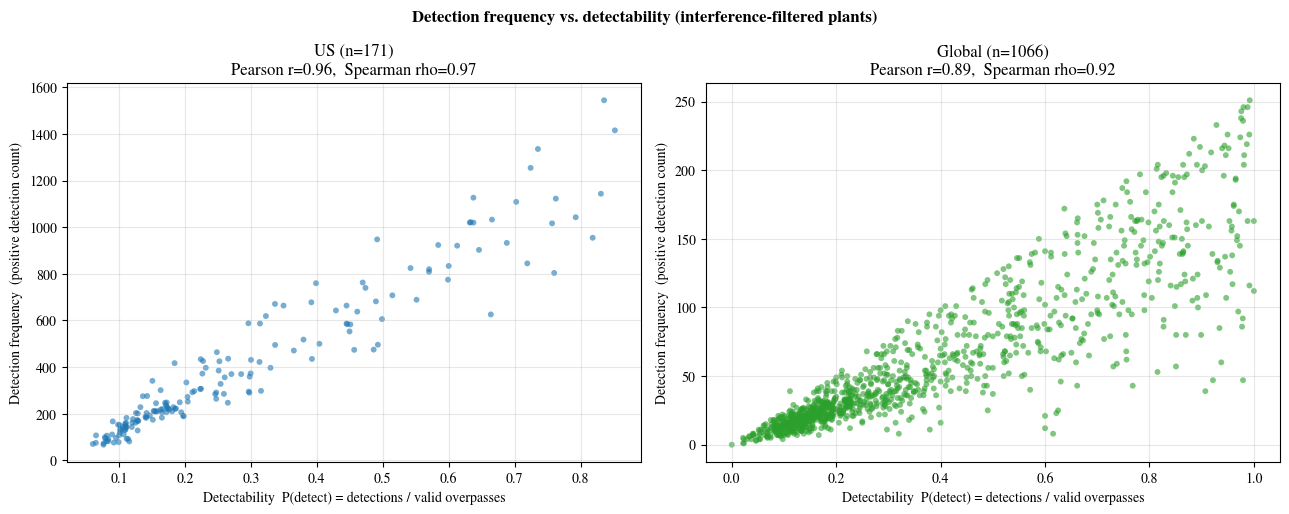

saved /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/detfreq_vs_detectability_correlation.png


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, (name, gdf, color) in zip(
        axes,
        [('US (n=%d)' % len(us_gdf_filtered), us_gdf_filtered, '#1f77b4'),
         ('Global (n=%d)' % len(global_gdf_filtered), global_gdf_filtered, '#2ca02c')]):
    gdf = gdf[gdf['n_obs'] > 0]  # detectability defined only with >=1 valid overpass
    ax.scatter(gdf['plume_probability'], gdf['pos_cnt'], s=18, alpha=0.6,
               edgecolor='none', color=color)
    ax.set_xlabel('Detectability  P(detect) = detections / valid overpasses')
    ax.set_ylabel('Detection frequency  (positive detection count)')
    pr, _ = pearsonr(gdf['pos_cnt'].astype(float), gdf['plume_probability'].astype(float))
    sr, _ = spearmanr(gdf['pos_cnt'].astype(float), gdf['plume_probability'].astype(float))
    ax.set_title(f'{name}\nPearson r={pr:.2f},  Spearman rho={sr:.2f}')
    ax.grid(alpha=0.3)
fig.suptitle('Detection frequency vs. detectability (interference-filtered plants)',
             fontweight='bold')
fig.tight_layout()
out = os.path.join(OUTPUT_DIR, 'detfreq_vs_detectability_correlation.png')
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('saved', out)
